# Customer Churn Prediction using Machine Learning

## Project Overview

This project aims to predict customer churn for a telecom company using machine learning techniques. By analyzing customer demographics, account information, subscribed services, and billing details, the model identifies customers who are likely to discontinue the service. Such predictions can help businesses implement targeted retention strategies, reduce customer attrition, and improve overall profitability.

### Business Objective

Develop a predictive model that can accurately identify customers who are likely to churn, enabling the telecom company to implement customer retention strategies and reduce revenue loss.


### Machine Learning Problem

- **Problem Type:** Supervised Machine Learning
- **Task:** Binary Classification
- **Target Variable:** `Churn`
- **Target Classes:** `Yes` and `No`

## Import Libraries

In [96]:
# ============================================================
# Import Required Libraries
# ============================================================

# Data Manipulation
import numpy as np
import pandas as pd
import os

# Data Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score
)

from sklearn.compose import ColumnTransformer

from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler
)

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# Model Saving
import joblib

# Ignore Future Warnings
import warnings
warnings.filterwarnings("ignore")

In [207]:
# ============================================================
# Load Dataset
# ============================================================

df = pd.read_csv("data/Telco-Customer-Churn.csv")

print(f"Dataset Shape : {df.shape}")

df.head()

Dataset Shape : (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Initial Data Exploration

Before cleaning or transforming the data, it is important to understand the dataset.

In this section, we inspect:

- Dataset dimensions
- Column names
- Data types
- Missing values
- Duplicate records
- Statistical summary

This helps identify potential data quality issues that need to be addressed before model training.

In [98]:
# ============================================================
# Basic Information
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [99]:
# ============================================================
# Statistical Summary
# ============================================================

df.describe(include="all")

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [100]:
# ============================================================
# Missing Values
# ============================================================

df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [101]:
# ============================================================
# Duplicate Records
# ============================================================

print(f"Duplicate Rows : {df.duplicated().sum()}")

Duplicate Rows : 0


In [102]:
# ============================================================
# Unique Values in Each Column
# ============================================================

for column in df.columns:
    print(f"{column} : {df[column].nunique()} unique values")

customerID : 7043 unique values
gender : 2 unique values
SeniorCitizen : 2 unique values
Partner : 2 unique values
Dependents : 2 unique values
tenure : 73 unique values
PhoneService : 2 unique values
MultipleLines : 3 unique values
InternetService : 3 unique values
OnlineSecurity : 3 unique values
OnlineBackup : 3 unique values
DeviceProtection : 3 unique values
TechSupport : 3 unique values
StreamingTV : 3 unique values
StreamingMovies : 3 unique values
Contract : 3 unique values
PaperlessBilling : 2 unique values
PaymentMethod : 4 unique values
MonthlyCharges : 1585 unique values
TotalCharges : 6531 unique values
Churn : 2 unique values


## Cleaning the `TotalCharges` Column

Although `TotalCharges` represents the total amount billed to a customer, it is stored as an **object** instead of a numeric data type.

This usually happens because the column contains blank spaces or invalid values, preventing Pandas from recognizing it as a numerical feature.

To make it suitable for analysis and machine learning, we first convert it into a numeric column. Any invalid values are converted into missing values (`NaN`), which are handled in the next step.

In [103]:
df[df["TotalCharges"]==" "]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [104]:
df["TotalCharges"] = df["TotalCharges"].replace(" ",0).astype(float)

In [105]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [106]:
df["customerID"].duplicated().sum()

0

In [107]:
df["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [108]:
df["Churn"].value_counts(normalize = True)*100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

# Exploratory Data Analysis

Exploratory Data Analysis helps uncover patterns, trends, and relationships within the dataset.

The objective is to understand customer behavior before building predictive models.

The analysis focuses on:

- Customer demographics
- Contract types
- Internet services
- Payment methods
- Monthly charges
- Customer tenure
- Churn distribution

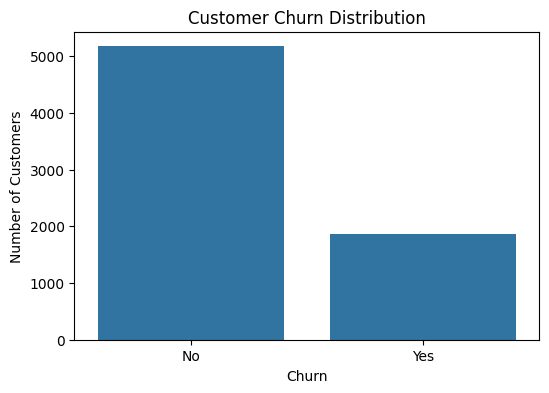

In [109]:
plt.figure(figsize=(6,4))

sns.countplot(data = df, x = "Churn")
plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")

plt.show()

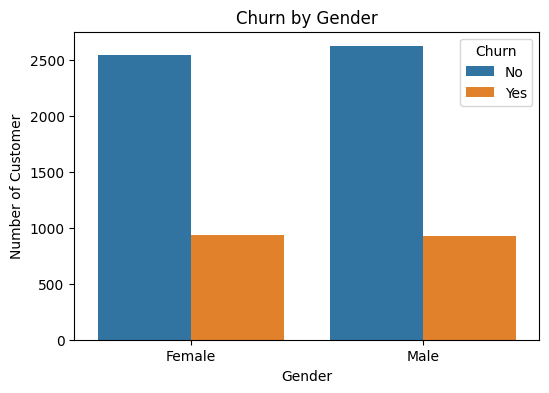

In [110]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "gender" , hue = "Churn")

plt.title("Churn by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customer")

plt.show()

In [111]:
pd.crosstab(df["gender"],df["Churn"],normalize = "index")*100

Churn,No,Yes
gender,,
Female,73.079128,26.920872
Male,73.839662,26.160338


In [112]:
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize = "index")*100

Churn,No,Yes
SeniorCitizen,,
0,76.393832,23.606168
1,58.318739,41.681261


Observation: Senior citizens have a substantially higher churn rate (41.68%) compared to non-senior citizens (23.61%). This suggests that senior citizen status may be an important factor associated with customer churn and warrants further investigation.

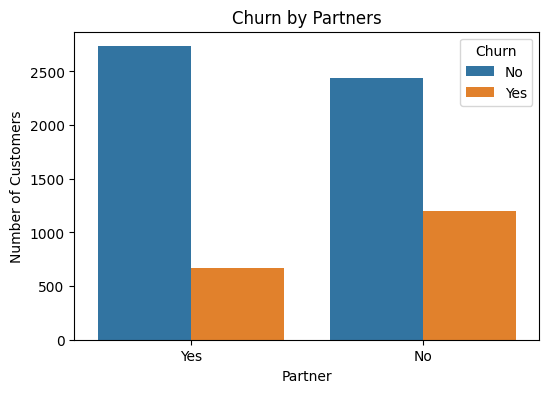

In [113]:
plt.figure(figsize= (6,4))
sns.countplot(data = df, x = "Partner",  hue = "Churn")

plt.title("Churn by Partners")
plt.xlabel("Partner")
plt.ylabel("Number of Customers")

plt.show()

In [114]:
pd.crosstab(df["Partner"] , df["Churn"], normalize = "index")*100

Churn,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


Customers with a partner have a churn rate of 19.66%, compared to 32.96% for customers without a partner—a difference of approximately 13 percentage points. This suggests that having a partner is associated with lower customer churn and may be an important retention-related characteristic. Further analysis is needed to determine whether this relationship is direct or influenced by other factors.

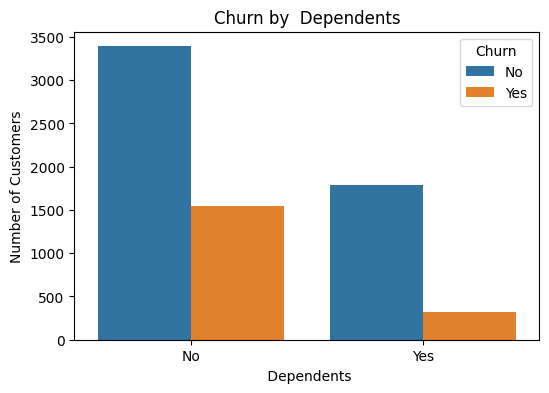

In [115]:
plt.figure(figsize= (6,4))
sns.countplot(data = df, x = "Dependents",  hue = "Churn")

plt.title("Churn by  Dependents")
plt.xlabel(" Dependents")
plt.ylabel("Number of Customers")

plt.show()

In [116]:
pd.crosstab(df["Dependents"] , df["Churn"], normalize = "index")*100

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.549763,15.450237


Observation: Customers with dependents have a churn rate of 15.45%, compared to 31.28% for customers without dependents—a difference of approximately 15.8 percentage points. This suggests that customers with dependents are substantially more likely to remain with the company. Dependency status appears to be an important characteristic associated with customer retention.

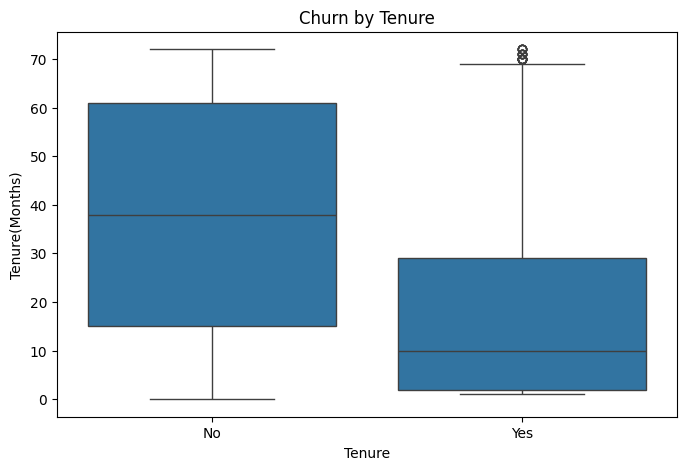

In [117]:
plt.figure(figsize =(8,5))

sns.boxplot(data = df, x = "Churn", y = "tenure")

plt.title("Churn by Tenure")
plt.xlabel("Tenure")
plt.ylabel("Tenure(Months)")

plt.show()

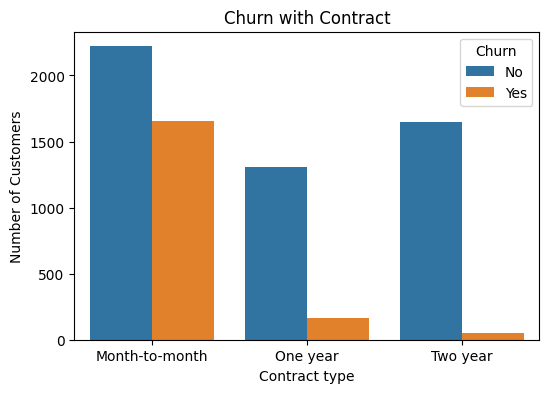

In [118]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "Contract", hue = "Churn")
plt.title("Churn with Contract")
plt.xlabel("Contract type")
plt.ylabel("Number of Customers")
plt.show()

In [119]:
pd.crosstab(df["Contract"], df["Churn"], normalize = "index")*100

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


Observation: Contract type is strongly associated with customer churn. Customers on month-to-month contracts have a churn rate of approximately 42.7%, compared to 11.3% for one-year contracts and only 2.8% for two-year contracts. This suggests that longer-term contractual commitments are associated with significantly higher customer retention.

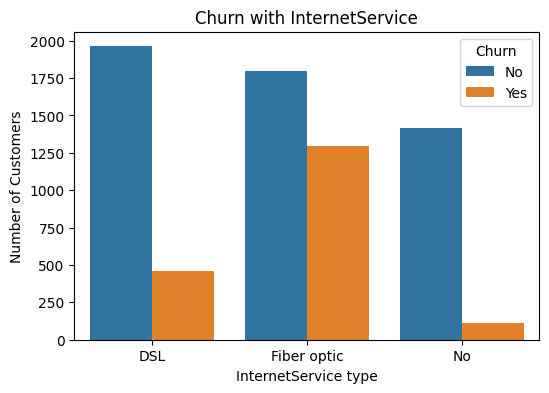

In [120]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "InternetService", hue = "Churn")
plt.title("Churn with InternetService")
plt.xlabel("InternetService type")
plt.ylabel("Number of Customers")
plt.show()

In [121]:
pd.crosstab(df["InternetService"], df["Churn"], normalize = "index")*100

Churn,No,Yes
InternetService,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Customers using Fiber optic internet have the highest churn rate (41.89%), more than double that of DSL customers (18.96%) and substantially higher than customers without internet service (7.40%). This indicates that Fiber optic customers are a high-risk segment and should be investigated further to understand the underlying drivers of churn

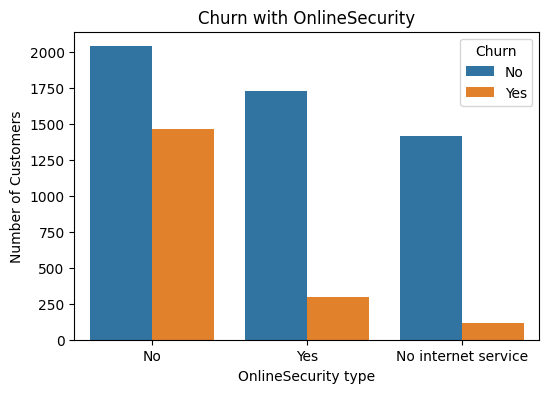

In [122]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "OnlineSecurity", hue = "Churn")
plt.title("Churn with OnlineSecurity")
plt.xlabel("OnlineSecurity type")
plt.ylabel("Number of Customers")
plt.show()

In [123]:
pd.crosstab(df["OnlineSecurity"], df["Churn"], normalize = "index")*100

Churn,No,Yes
OnlineSecurity,,
No,58.233276,41.766724
No internet service,92.595020,7.404980
Yes,85.388806,14.611194


Observation: Customers without Online Security have a churn rate of 41.77%, compared to 14.61% for customers who subscribe to the service. This strong association suggests that customers using Online Security are substantially more likely to remain with the company. Online Security appears to be an important retention-related service.

The churn rate for "No internet service" is exactly the same as what we observed for the InternetService variable.

That's because:If a customer has No Internet Service, they automatically cannot have Online Security.

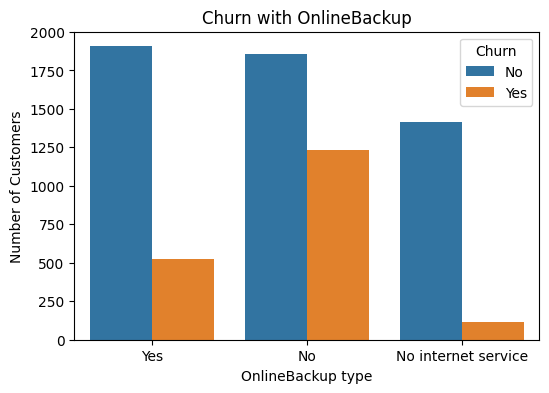

In [124]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "OnlineBackup", hue = "Churn")
plt.title("Churn with OnlineBackup")
plt.xlabel("OnlineBackup type")
plt.ylabel("Number of Customers")
plt.show()

In [125]:
pd.crosstab(df["OnlineBackup"], df["Churn"], normalize = "index")*100

Churn,No,Yes
OnlineBackup,,
No,60.071244,39.928756
No internet service,92.595020,7.404980
Yes,78.468506,21.531494


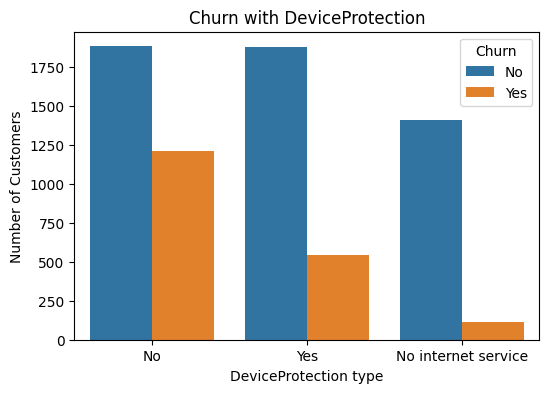

In [208]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "DeviceProtection", hue = "Churn")
plt.title("Churn with DeviceProtection")
plt.xlabel("DeviceProtection type")
plt.ylabel("Number of Customers")
plt.show()

In [127]:
pd.crosstab(df["DeviceProtection"], df["Churn"], normalize = "index")*100

Churn,No,Yes
DeviceProtection,,
No,60.872375,39.127625
No internet service,92.595020,7.404980
Yes,77.497936,22.502064


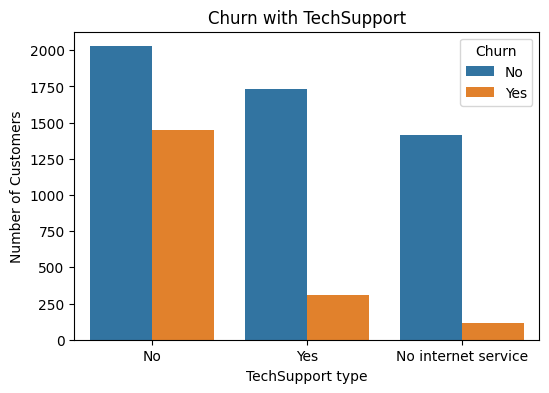

In [128]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "TechSupport", hue = "Churn")
plt.title("Churn with TechSupport")
plt.xlabel("TechSupport type")
plt.ylabel("Number of Customers")
plt.show()

In [129]:
pd.crosstab(df["TechSupport"], df["Churn"], normalize = "index")*100

Churn,No,Yes
TechSupport,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


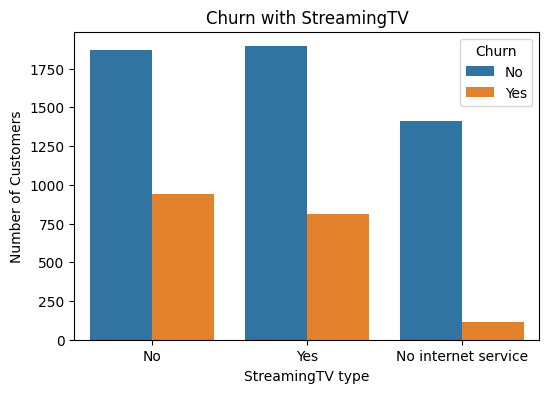

In [130]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "StreamingTV", hue = "Churn")
plt.title("Churn with StreamingTV")
plt.xlabel("StreamingTV type")
plt.ylabel("Number of Customers")
plt.show()

In [131]:
pd.crosstab(df["StreamingTV"], df["Churn"], normalize = "index")*100

Churn,No,Yes
StreamingTV,,
No,66.476868,33.523132
No internet service,92.595020,7.404980
Yes,69.929812,30.070188


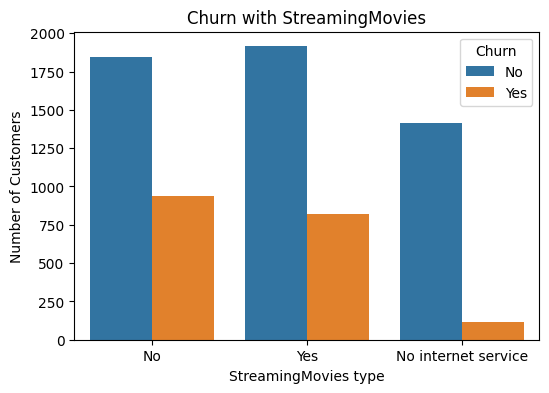

In [132]:
plt.figure(figsize = (6,4))

sns.countplot(data = df , x = "StreamingMovies", hue = "Churn")
plt.title("Churn with StreamingMovies")
plt.xlabel("StreamingMovies type")
plt.ylabel("Number of Customers")
plt.show()

In [133]:
pd.crosstab(df["StreamingMovies"], df["Churn"], normalize = "index")*100

Churn,No,Yes
StreamingMovies,,
No,66.319569,33.680431
No internet service,92.595020,7.404980
Yes,70.058565,29.941435


Support and protection services (Online Security, Tech Support, Online Backup, and Device Protection) consistently show strong associations with lower churn, suggesting that customers who adopt these value-added services are substantially more likely to remain with the company. In contrast, entertainment-oriented services such as Streaming TV and Streaming Movies exhibit only weak relationships with churn, indicating they are less influential in customer retention.

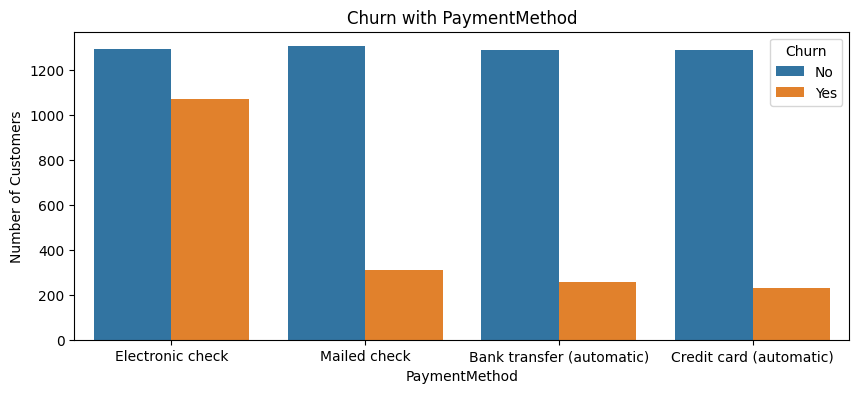

In [134]:
plt.figure(figsize = (10,4))

sns.countplot(data = df , x = "PaymentMethod", hue = "Churn")
plt.title("Churn with PaymentMethod")
plt.xlabel("PaymentMethod")
plt.ylabel("Number of Customers")
plt.show()

In [135]:
pd.crosstab(df["PaymentMethod"], df["Churn"], normalize = "index")*100

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


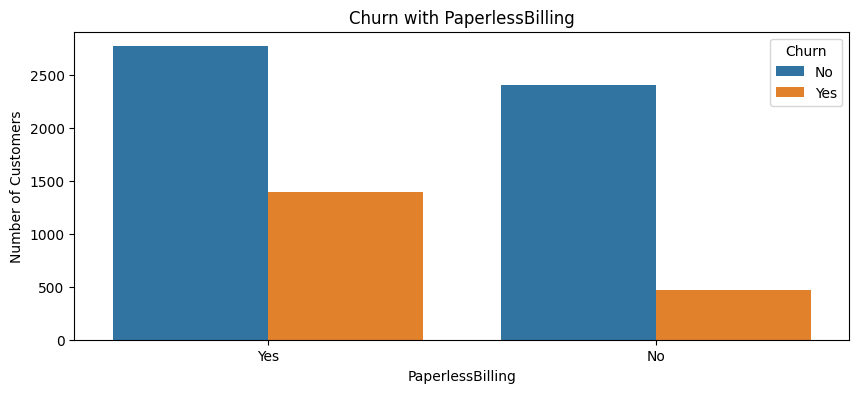

In [136]:
plt.figure(figsize = (10,4))

sns.countplot(data = df , x = "PaperlessBilling", hue = "Churn")
plt.title("Churn with PaperlessBilling")
plt.xlabel("PaperlessBilling")
plt.ylabel("Number of Customers")
plt.show()

In [137]:
pd.crosstab(df["PaperlessBilling"], df["Churn"], normalize = "index")*100

Churn,No,Yes
PaperlessBilling,,
No,83.669916,16.330084
Yes,66.434908,33.565092


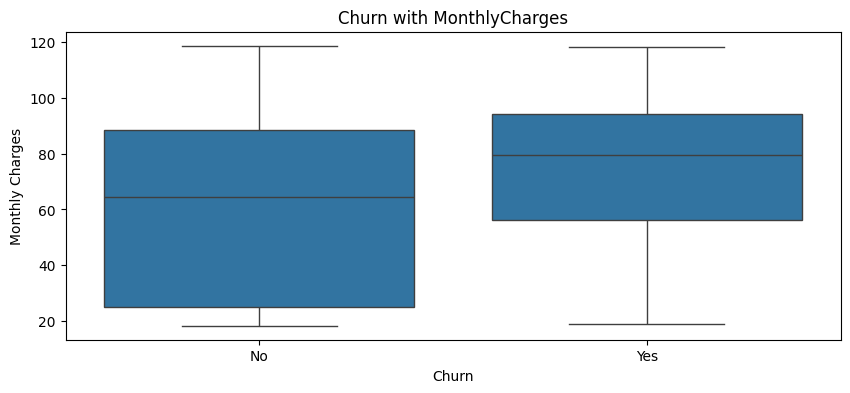

In [138]:
plt.figure(figsize = (10,4))

sns.boxplot(data = df , x = "Churn", y = "MonthlyCharges")
plt.title("Churn with MonthlyCharges")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")
plt.show()

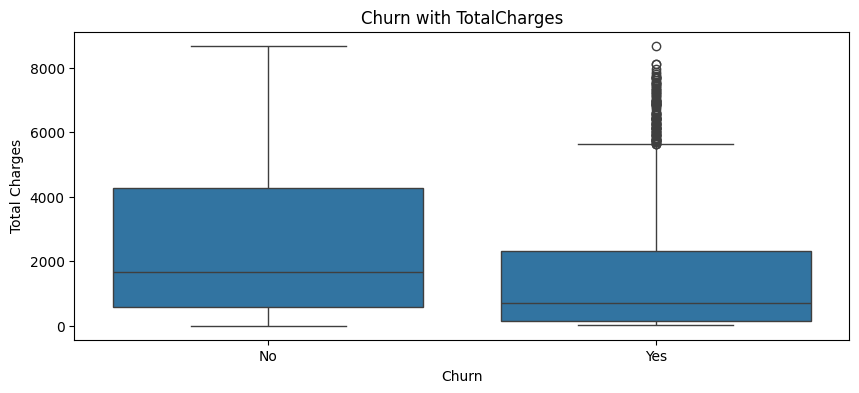

In [139]:
plt.figure(figsize = (10,4))

sns.boxplot(data = df , x = "Churn", y = "TotalCharges")
plt.title("Churn with TotalCharges")
plt.xlabel("Churn")
plt.ylabel("Total Charges")
plt.show()

# Model Building

After exploring and cleaning the dataset, the next step is to prepare the data for machine learning.

Before training any model, the dataset is divided into training and testing sets.

This ensures that the model is trained on one portion of the data and evaluated on completely unseen data, providing a reliable estimate of how well it will perform on new customers.

Splitting the data before preprocessing is also essential to prevent **Data Leakage**, where information from the test set unintentionally influences the training process.

## Train-Test Split

The dataset is divided into:

- **Training Set (80%)** – Used to train the machine learning model.
- **Testing Set (20%)** – Used to evaluate the model on unseen data.

The target variable (**Churn**) is separated from the predictor variables before splitting the dataset.

In [140]:
df.drop(columns = "customerID" , inplace = True)

In [141]:
X = df.drop(columns = "Churn")

In [142]:
y = df["Churn"]

In [143]:
X_train , X_test , y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y)

In [144]:
encoder = OneHotEncoder(drop = "first", handle_unknown = "ignore" , sparse_output = False)

In [145]:
encoder.fit(X_train)

OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

In [146]:
X_train_encoded = encoder.transform(X_train)
X_test_encoded = encoder.transform(X_test)

In [147]:
print(X_train.shape)
print(X_test.shape)

(5634, 19)
(1409, 19)


In [148]:
encoder.categories_

[array(['Female', 'Male'], dtype=object),
 array([0, 1], dtype=int64),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'Yes'], dtype=object),
 array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
        51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
        68, 69, 70, 71, 72], dtype=int64),
 array(['No', 'Yes'], dtype=object),
 array(['No', 'No phone service', 'Yes'], dtype=object),
 array(['DSL', 'Fiber optic', 'No'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 array(['No', 'No internet service', 'Yes'], dtype=object),
 a

In [149]:
categorical_cols = X_train.select_dtypes(include = "object").columns
print(categorical_cols)

Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')


In [150]:
numerical_cols = X_train.select_dtypes(exclude = "object").columns
print(numerical_cols)

Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object')


In [151]:
preprocessor = ColumnTransformer(
    transformers = [
        ("cat" , 
         OneHotEncoder
         (
             drop = "first", 
             handle_unknown = "ignore",
             sparse_output = False
         ),
         categorical_cols
        ),
         (
             "num" , StandardScaler(), numerical_cols)
         ]
)

In [152]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('cat',
                                 OneHotEncoder(drop='first',
                                               handle_unknown='ignore',
                                               sparse_output=False),
                                 Index(['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod'],
      dtype='object')),
                                ('num', StandardScaler(),
                                 Index(['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges'], dtype='object'))])

In [153]:
X_train_processed = preprocessor.transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [154]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(5634, 30)
(1409, 30)


In [155]:
preprocessor.get_feature_names_out()

array(['cat__gender_Male', 'cat__Partner_Yes', 'cat__Dependents_Yes',
       'cat__PhoneService_Yes', 'cat__MultipleLines_No phone service',
       'cat__MultipleLines_Yes', 'cat__InternetService_Fiber optic',
       'cat__InternetService_No',
       'cat__OnlineSecurity_No internet service',
       'cat__OnlineSecurity_Yes', 'cat__OnlineBackup_No internet service',
       'cat__OnlineBackup_Yes',
       'cat__DeviceProtection_No internet service',
       'cat__DeviceProtection_Yes',
       'cat__TechSupport_No internet service', 'cat__TechSupport_Yes',
       'cat__StreamingTV_No internet service', 'cat__StreamingTV_Yes',
       'cat__StreamingMovies_No internet service',
       'cat__StreamingMovies_Yes', 'cat__Contract_One year',
       'cat__Contract_Two year', 'cat__PaperlessBilling_Yes',
       'cat__PaymentMethod_Credit card (automatic)',
       'cat__PaymentMethod_Electronic check',
       'cat__PaymentMethod_Mailed check', 'num__SeniorCitizen',
       'num__tenure', 'num__Mont

# Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for binary classification problems.

In this project, the objective is to classify customers into one of two categories:

- **Yes** → Customer is likely to churn.
- **No** → Customer is likely to stay.

Unlike linear regression, Logistic Regression predicts the probability of a customer belonging to a particular class using the sigmoid function. Based on a classification threshold (default = 0.5), the predicted probability is converted into a class label.

Since our dataset contains both numerical and categorical features, the preprocessing pipeline is applied before training the Logistic Regression model.

The trained model is then evaluated using multiple performance metrics to understand how well it identifies customers who are likely to churn.

In [156]:
model = LogisticRegression(random_state = 42)

In [157]:
model.fit(X_train_processed , y_train)

LogisticRegression(random_state=42)

## Model Prediction

After training, the model is used to predict the churn status of customers in the testing dataset.

The predictions are then compared with the actual values to evaluate model performance.

In [158]:
y_pred = model.predict(X_test_processed)
print(y_pred)

['No' 'Yes' 'No' ... 'No' 'No' 'No']


## Model Evaluation

To evaluate the performance of the Logistic Regression model, the following metrics are used:

- Accuracy
- Confusion Matrix
- Precision
- Recall
- F1-Score

These metrics provide a comprehensive understanding of the model's ability to correctly classify customers who are likely to churn.

In [159]:
accuracy = accuracy_score(y_test , y_pred)
print(f"Accuracy : {accuracy*100 :.2f}%")

Accuracy : 80.70%


In [160]:
print(confusion_matrix(y_test, y_pred))

[[927 108]
 [164 210]]


In [161]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

          No       0.85      0.90      0.87      1035
         Yes       0.66      0.56      0.61       374

    accuracy                           0.81      1409
   macro avg       0.76      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [162]:
tree = DecisionTreeClassifier(random_state = 42)
tree

DecisionTreeClassifier(random_state=42)

In [163]:
tree.fit(X_train_processed , y_train)

DecisionTreeClassifier(random_state=42)

In [164]:
y_pred_tree = tree.predict(X_test_processed)

In [165]:
tree_accuracy = accuracy_score(y_test , y_pred_tree)
print(tree_accuracy)

0.7267565649396736


In [166]:
tree_confusion_matrix = confusion_matrix(y_test , y_pred_tree)
print(tree_confusion_matrix)

[[846 189]
 [196 178]]


In [167]:
tree_classification_report = classification_report(y_test , y_pred_tree)
print(tree_classification_report)

              precision    recall  f1-score   support

          No       0.81      0.82      0.81      1035
         Yes       0.49      0.48      0.48       374

    accuracy                           0.73      1409
   macro avg       0.65      0.65      0.65      1409
weighted avg       0.73      0.73      0.73      1409



In [168]:
train_accuracy = tree.score(X_train_processed , y_train)
test_accuracy = tree.score(X_test_processed , y_test)

print(train_accuracy)
print(test_accuracy)

0.9980475683351083
0.7267565649396736


In [169]:
tree_pruned = DecisionTreeClassifier(
    max_depth = 3 , 
    random_state = 42
)

In [170]:
tree_pruned.fit(X_train_processed , y_train)

y_pred_pruned = tree_pruned.predict(X_test_processed)

In [171]:
print("Test accuracy : ", tree_pruned.score(X_train_processed,y_train))
print("Test Accuracu : ", tree_pruned.score(X_test_processed , y_test))

Test accuracy :  0.791089811856585
Test Accuracu :  0.78708303761533


In [172]:
rf = RandomForestClassifier(random_state = 42)

In [173]:
rf.fit(X_train_processed , y_train)

RandomForestClassifier(random_state=42)

In [174]:
y_pred_rf = rf.predict(X_test_processed)

In [175]:
print("Train Accuracy : ", rf.score(X_train_processed , y_train))
print("Test Accuracy : ", rf.score(X_test_processed , y_test))

Train Accuracy :  0.9980475683351083
Test Accuracy :  0.7927608232789212


In [176]:
print(confusion_matrix(y_test , y_pred_rf))

[[927 108]
 [184 190]]


In [177]:
print(classification_report(y_test , y_pred_rf))

              precision    recall  f1-score   support

          No       0.83      0.90      0.86      1035
         Yes       0.64      0.51      0.57       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [178]:
param_grid ={
    "max_depth" : [2,3,4,5,6],
    "min_samples_split" : [2,5,10]

}

# Hyperparameter Tuning using GridSearchCV

Machine learning models often contain parameters that control how they learn from data. These parameters, known as **hyperparameters**, are not learned during training and must be specified before the model is built.

Instead of manually trying different combinations, **GridSearchCV** systematically evaluates multiple hyperparameter combinations using **cross-validation** to identify the configuration that produces the best performance.

For the Decision Tree model, the following hyperparameters are tuned:

- **max_depth** – Controls the maximum depth of the tree, helping prevent overfitting.
- **min_samples_split** – Specifies the minimum number of samples required to split an internal node.

The combination with the highest cross-validation score is selected as the optimal model.

In [179]:
grid= GridSearchCV(
    estimator = DecisionTreeClassifier(random_state = 42),
    param_grid = param_grid,
    cv = 5,
    scoring = "accuracy",
    n_jobs = -1
)

In [180]:
grid.fit(X_train_processed , y_train)

GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [2, 3, 4, 5, 6],
                         'min_samples_split': [2, 5, 10]},
             scoring='accuracy')

In [181]:
print(grid.best_params_)

{'max_depth': 3, 'min_samples_split': 2}


In [182]:
best_tree = grid.best_estimator_
print(best_tree)

DecisionTreeClassifier(max_depth=3, random_state=42)


In [183]:
y_pred_best = best_tree.predict(X_test_processed)

In [184]:
y_prob = model.predict_proba(X_test_processed)[:, 1]

In [185]:
fpr, tpr , threshold = roc_curve(y_test, y_prob , pos_label = "Yes")

In [186]:
auc = roc_auc_score(y_test , y_prob)
print("Auc Score", auc)

Auc Score 0.8421710713270816


In [187]:
os.makedirs("images", exist_ok=True)

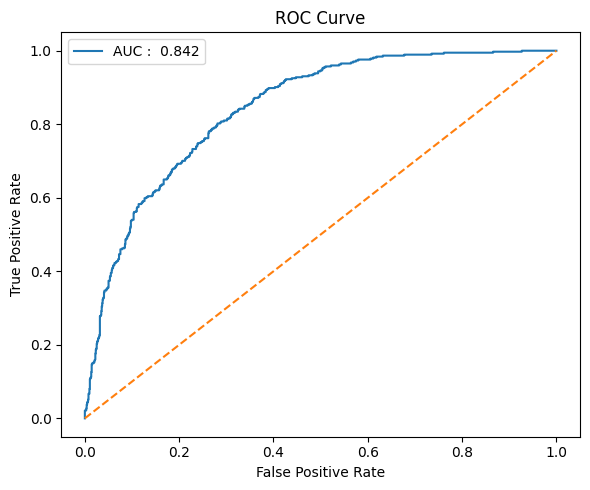

In [188]:
plt.figure(figsize = (6,5))

plt.plot(fpr, tpr, label = f"AUC : {auc: .3f}")
plt.plot([0,1],[0,1],linestyle = "--")

plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()

plt.tight_layout()
plt.savefig("images/roc_curve.png", dpi=300)
plt.show()

# Feature Importance

Building an accurate machine learning model is only part of the solution. It is equally important to understand **why** the model makes its predictions.

Feature Importance measures the contribution of each feature toward predicting customer churn. By identifying the most influential variables, businesses can better understand the key factors driving customer retention and customer loss.

In this project, the feature importance values obtained from the trained model are analyzed and visualized to identify the variables that have the greatest impact on churn prediction.

These insights can support data-driven business decisions, allowing organizations to focus their customer retention strategies on the factors that matter the most.

In [189]:
print(best_tree.feature_importances_)

[0.         0.         0.         0.         0.         0.
 0.44103112 0.         0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.
 0.         0.         0.         0.01298979 0.         0.
 0.         0.         0.         0.51984355 0.         0.02613554]


In [190]:
feature_names = preprocessor.get_feature_names_out()

In [191]:
importance_df = pd.DataFrame({
    "Features" : feature_names,
    "Importance" : best_tree.feature_importances_
})

In [192]:
importance_df = importance_df.sort_values(
    by = "Importance", 
    ascending = False
)

In [193]:
importance_df

,Features,Importance
27,num__tenure,0.519844
6,cat__InternetService_Fiber optic,0.441031
29,num__TotalCharges,0.026136
21,cat__Contract_Two year,0.012990
16,cat__StreamingTV_No internet service,0.000000
28,num__MonthlyCharges,0.000000
26,num__SeniorCitizen,0.000000
25,cat__PaymentMethod_Mailed check,0.000000
24,cat__PaymentMethod_Electronic check,0.000000
23,cat__PaymentMethod_Credit card (automatic),0.000000


In [194]:
top_features = importance_df.head(10)

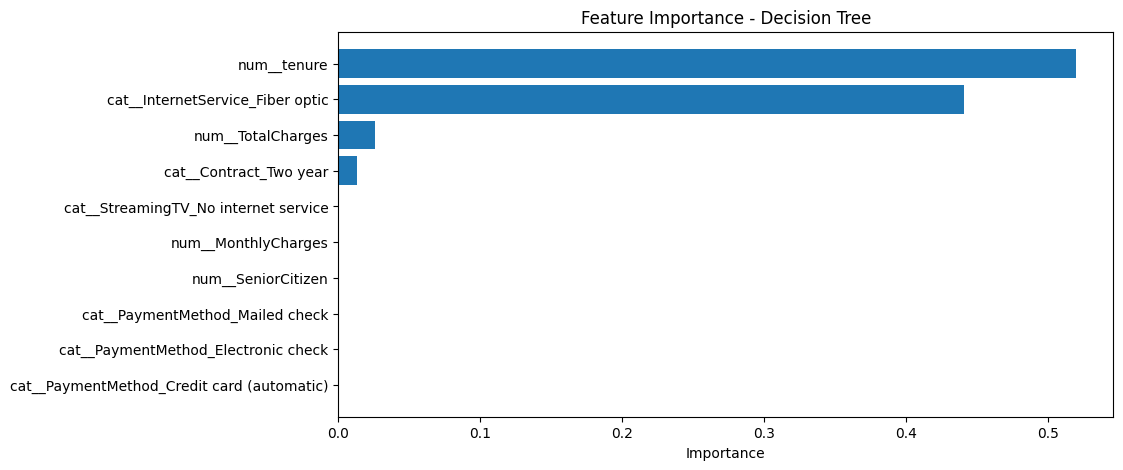

In [204]:
plt.figure(figsize = (10,5))

plt.barh(
    top_features["Features"],
    top_features["Importance"]
)

plt.gca().invert_yaxis()

plt.xlabel("Importance")
plt.title("Feature Importance - Decision Tree")
plt.savefig("images/feature_importance.png", dpi = 300)

plt.show()

## Business Interpretation

The feature importance analysis indicates that **Tenure**, **Internet Service (Fiber Optic)**, and **Total Charges** are among the most influential factors affecting customer churn.

Customers with shorter tenure and fiber optic internet service tend to exhibit a higher likelihood of churning, while customers with longer tenure generally show stronger customer retention.

These insights provide valuable information for business stakeholders, enabling targeted retention strategies such as personalized offers, loyalty programs, and proactive customer support for high-risk customers.

# Save the Trained Model

Once the model has been trained and evaluated, it is saved for future use.

Saving the trained model eliminates the need to retrain it every time a prediction is required. Along with the model, the preprocessing pipeline is also saved to ensure that new customer data undergoes the same transformations used during training.

This approach is essential for deploying machine learning models in real-world applications, where predictions are made on new, unseen data.

In [196]:
joblib.dump(model , "logistic_model.pkl")

['logistic_model.pkl']

## Save the Preprocessing Pipeline

The preprocessing pipeline is saved separately to maintain consistency between training and prediction.

When new customer data is received, it must undergo the same preprocessing steps—including encoding categorical features and scaling numerical features—before being passed to the trained model.

Saving the preprocessing pipeline ensures that future predictions are performed reliably and consistently.

In [197]:
joblib.dump(preprocessor , "preprocessor.pkl")

['preprocessor.pkl']

# Predict Churn for New Customers

After saving the trained model and preprocessing pipeline, they can be loaded to make predictions for new customer data.

Instead of retraining the model, the saved model is reused to predict whether a new customer is likely to churn.

This demonstrates how machine learning models are typically used in real-world applications, where predictions are made on unseen customer records.

In [198]:
loaded_model = joblib.load("logistic_model.pkl")
loaded_preprocessor = joblib.load("preprocessor.pkl")

In [199]:
customers = pd.DataFrame({

    "gender": ["Female", "Male", "Female", "Male", "Female"],

    "SeniorCitizen": [0, 0, 1, 0, 1],

    "Partner": ["Yes", "Yes", "No", "Yes", "No"],

    "Dependents": ["No", "Yes", "No", "Yes", "No"],

    "tenure": [3, 60, 12, 72, 24],

    "PhoneService": ["Yes"] * 5,

    "MultipleLines": [
        "No",
        "Yes",
        "Yes",
        "No",
        "Yes"
    ],

    "InternetService": [
        "Fiber optic",
        "DSL",
        "Fiber optic",
        "DSL",
        "Fiber optic"
    ],

    "OnlineSecurity": [
        "No",
        "Yes",
        "No",
        "Yes",
        "No"
    ],

    "OnlineBackup": [
        "No",
        "Yes",
        "Yes",
        "Yes",
        "No"
    ],

    "DeviceProtection": [
        "No",
        "Yes",
        "No",
        "Yes",
        "No"
    ],

    "TechSupport": [
        "No",
        "Yes",
        "No",
        "Yes",
        "No"
    ],

    "StreamingTV": [
        "Yes",
        "No",
        "Yes",
        "Yes",
        "Yes"
    ],

    "StreamingMovies": [
        "Yes",
        "No",
        "Yes",
        "Yes",
        "Yes"
    ],

    "Contract": [
        "Month-to-month",
        "Two year",
        "Month-to-month",
        "Two year",
        "One year"
    ],

    "PaperlessBilling": [
        "Yes",
        "No",
        "Yes",
        "No",
        "Yes"
    ],

    "PaymentMethod": [
        "Electronic check",
        "Bank transfer (automatic)",
        "Electronic check",
        "Credit card (automatic)",
        "Mailed check"
    ],

    "MonthlyCharges": [
        89.5,
        54.3,
        101.2,
        61.7,
        79.4
    ],

    "TotalCharges": [
        268.5,
        3258.0,
        1214.4,
        4442.4,
        1905.6
    ]

})

customers

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,Female,0,Yes,No,3,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,89.5,268.5
1,Male,0,Yes,Yes,60,Yes,Yes,DSL,Yes,Yes,Yes,Yes,No,No,Two year,No,Bank transfer (automatic),54.3,3258.0
2,Female,1,No,No,12,Yes,Yes,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,101.2,1214.4
3,Male,0,Yes,Yes,72,Yes,No,DSL,Yes,Yes,Yes,Yes,Yes,Yes,Two year,No,Credit card (automatic),61.7,4442.4
4,Female,1,No,No,24,Yes,Yes,Fiber optic,No,No,No,No,Yes,Yes,One year,Yes,Mailed check,79.4,1905.6


## Load the Saved Model

The trained Logistic Regression model and the preprocessing pipeline are loaded from disk.

Loading the saved files allows future predictions to be made without repeating the training process.

In [200]:
customers_processed = loaded_preprocessor.transform(customers)

predictions = loaded_model.predict(customers_processed)

probabilities = loaded_model.predict_proba(customers_processed)

## Predict Customer Churn

The new customer data is first transformed using the saved preprocessing pipeline.

The processed data is then passed to the trained Logistic Regression model to predict:

- Whether the customer is likely to churn.
- The probability of the customer staying.
- The probability of the customer churning.

These probabilities provide additional insight into the model's confidence and can support business decision-making.

In [201]:
results = customers.copy()

results["Prediction"] = predictions

results["Probability of Staying"] = probabilities[:,0]

results["Probability of Churning"] = probabilities[:,1]

results["Probability of Staying"] = (
    results["Probability of Staying"] * 100).round(2)

results["Probability of Churning"] = (
    results["Probability of Churning"] * 100).round(2)

results

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Prediction,Probability of Staying,Probability of Churning
0,Female,0,Yes,No,3,Yes,No,Fiber optic,No,No,...,Yes,Yes,Month-to-month,Yes,Electronic check,89.5,268.5,Yes,21.96,78.04
1,Male,0,Yes,Yes,60,Yes,Yes,DSL,Yes,Yes,...,No,No,Two year,No,Bank transfer (automatic),54.3,3258.0,No,99.31,0.69
2,Female,1,No,No,12,Yes,Yes,Fiber optic,No,Yes,...,Yes,Yes,Month-to-month,Yes,Electronic check,101.2,1214.4,Yes,22.53,77.47
3,Male,0,Yes,Yes,72,Yes,No,DSL,Yes,Yes,...,Yes,Yes,Two year,No,Credit card (automatic),61.7,4442.4,No,99.37,0.63
4,Female,1,No,No,24,Yes,Yes,Fiber optic,No,No,...,Yes,Yes,One year,Yes,Mailed check,79.4,1905.6,Yes,44.37,55.63


In [202]:
results.insert(
    0,
    "Customer",
    [
        "New Customer",
        "Loyal Customer",
        "High Bill Customer",
        "Long-Term Customer",
        "Medium Risk Customer"
    ]
)

In [203]:
prediction_summary = results[[
    "Customer",
    "Prediction",
    "Probability of Staying",
    "Probability of Churning"
]]

prediction_summary

,Customer,Prediction,Probability of Staying,Probability of Churning
0,New Customer,Yes,21.96,78.04
1,Loyal Customer,No,99.31,0.69
2,High Bill Customer,Yes,22.53,77.47
3,Long-Term Customer,No,99.37,0.63
4,Medium Risk Customer,Yes,44.37,55.63


## Business Interpretation

The prediction results demonstrate how the trained model can identify customers with different levels of churn risk.

Customers with a higher probability of churning can be targeted with retention strategies such as personalized offers, loyalty programs, or proactive customer support.

This enables businesses to focus their efforts on customers who are most likely to leave, helping improve customer retention while reducing unnecessary intervention for low-risk customers.